This is for algorithmic experimentation for how to produce a PSF on a specific center in ~1 ms or less.


In [1]:
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

from jwst import datamodels

from tqdm.auto import tqdm

from scipy import interpolate

In [2]:
import os
os.environ['STPSF_PATH'] = os.path.expanduser('~/.cache/stpsf-data')

import stpsf

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')  # the ra and dec would have a delta in an inference loop so is different each time
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

The below should be replaced with ``stpsf.setup_sim_to_match_file(str(n6791fits[0]))`` once that works

In [4]:
nrs = stpsf.NIRSpec()
nrs.detector = dm0.meta.instrument.detector
nrs.filter = dm0.meta.instrument.filter
nrs.disperser = dm0.meta.instrument.grating

xdet, ydet = swcs.transform('detector', 'sca', *np.indices(slit.data.shape)[::-1])
nrs.detector_position = (np.mean(xdet), np.mean(ydet))

nrs.load_wss_opd_by_date(Time(dm0.meta.exposure.mid_time, format='mjd'))

nrs.image_mask = 'Single MSA open shutter'

iterating query, tdelta=3.0

MAST OPD query around UTC: 60136.5904089294
                        MJD: 60136.5904089294

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2023071203-NRCA3_FP1-1.fits
	Date (MJD):	 60136.5363
	Delta time:	 -0.0542 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/R2023071403-NRCA3_FP1-1.fits
	Date (MJD):	 60138.8979
	Delta time:	 2.3075 days
User requested choosing OPD time closest in time to 60136.5904089294, which is R2023071203-NRCA3_FP1-1.fits, delta time -0.054 days
Importing and format-converting OPD from /home/erik/.cache/stpsf-data/MAST_JWST_WSS_OPDs/R2023071203-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)


In [5]:
msa_slit_width = 0.2 #u.arcsec
msa_slit_height = 0.46 #u.arcsec

offset0_x = slit.source_xpos*msa_slit_width
offset0_y = slit.source_ypos*msa_slit_height

nrs.options.update({'source_offset_x': offset0_x, 
                    'source_offset_y': offset0_y})

In [6]:
%%time

psf = nrs.calc_psf(monochromatic=1.1e-6, oversample=9)

CPU times: user 13.3 s, sys: 1.44 s, total: 14.8 s
Wall time: 4.86 s


In [7]:
%%time

nrs.options.update({'source_offset_x': offset0_x + 0.01, 
                    'source_offset_y': offset0_y})

psf = nrs.calc_psf(monochromatic=1.1e-6, oversample=9)

CPU times: user 13 s, sys: 1.36 s, total: 14.4 s
Wall time: 4.91 s


So we need to accelerate this somehow.

# Make data

In [8]:
n = 1024
path = Path('psfarrs.npz')

if path.is_file():
    data = np.load(path)

    psfarrs = data['psfarrs']
    psfxs = data['xs']
    psfys = data['ys']

    if len(psfxs) == len(psfys) == len(psfarrs) == n:
        print('Loaded precomputed PSF array')
    else:
        print('Precomputed PSF array has wrong shape, recomputing')
        psfarrs = None

if psfarrs is None:
    psfxs = (np.random.rand(n)-0.5)*msa_slit_width
    psfys = (np.random.rand(n)-0.5)*msa_slit_height

    psfarrs = []
    for x, y in tqdm(list(zip(psfxs, psfys))):
        nrs.options.update({'source_offset_x': x, 
                            'source_offset_y': y})
        psf = nrs.calc_psf(fov_pixels=20, monochromatic=1.1e-6, oversample=8)
        psfarrs.append(psf['OVERDIST'].data)

    psfarrs = np.array(psfarrs)
    np.savez('psfarrs.npz', psfarrs=psfarrs, xs=psfxs, ys=psfys)

psfarrs.shape

Loaded precomputed PSF array


(1024, 160, 160)

Double-check this makes sense by looking at a few random ones.

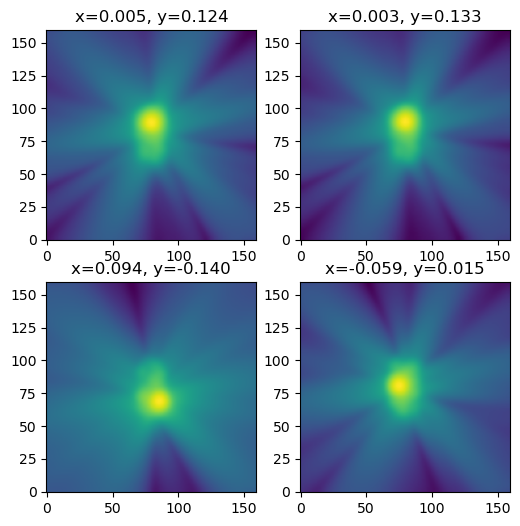

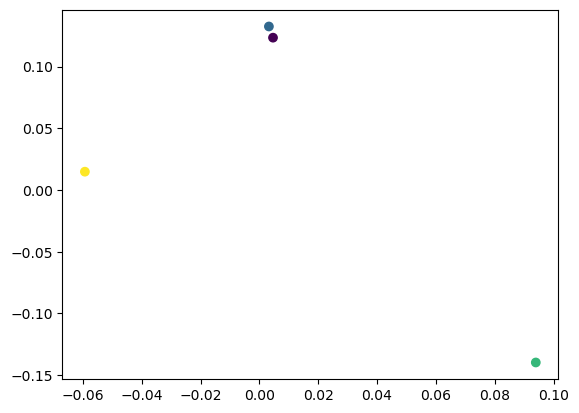

In [9]:
samp_idx = np.random.permutation(len(psfarrs))[:4]
fig, axs = plt.subplots(2, 2, figsize=(6, 6))
for i, idx in enumerate(samp_idx):
    axs.ravel()[i].imshow(np.log10(psfarrs[idx]), origin='lower')
    axs.ravel()[i].set_title(f'x={psfxs[idx]:.3f}, y={psfys[idx]:.3f}')

plt.figure()
plt.scatter(psfxs[samp_idx], psfys[samp_idx], c=np.arange(len(samp_idx)), cmap='viridis')

# Interpolation

First try `scipy.interpolate` methods

In [10]:
%%time 

points_xind, points_yind = np.indices(psfarrs.shape[1:])
points_xind = np.tile(points_xind, (len(psfarrs), 1, 1))
points_yind = np.tile(points_yind, (len(psfarrs), 1, 1))

points_xcen = np.tile(psfxs[:, np.newaxis, np.newaxis], (1, psfarrs.shape[1], psfarrs.shape[2]))
points_ycen = np.tile(psfys[:, np.newaxis, np.newaxis], (1, psfarrs.shape[1], psfarrs.shape[2]))

points = (points_xcen.ravel(), points_ycen.ravel(), points_xind.ravel(), points_yind.ravel())

CPU times: user 12.6 ms, sys: 26.8 ms, total: 39.4 ms
Wall time: 39.7 ms


In [11]:
#%%time
#res = interpolate.griddata(points, psfarrs.ravel(), (0.0, 0.0, points_xind[0].ravel(), points_yind[0].ravel()), method='linear', fill_value=np.nan)

The above doesn't finish in less than a minute so clearly impractical.

In [12]:
#%%time
#apoints = np.array(points)
#ier = interpolate.LinearNDInterpolator(apoints.T, psfarrs.ravel())

Also doesn't run in less than a minute...

In [13]:
%%time
apoints = np.array(points)
ier = interpolate.RBFInterpolator(apoints.T, psfarrs.ravel())

CPU times: user 238 ms, sys: 57.6 ms, total: 296 ms
Wall time: 297 ms


MemoryError: (unable to allocate 687195029504025 bytes)

The above methods might work with much smaller grid sampling, but instead lets try ML methods.

# Autoencoder approach

Start with just a MLP-based autoencoder and see how it does.

In [61]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

rkey = jax.random.PRNGKey(42)

In [347]:
npsfpx = int(np.prod(psfarrs.shape[1:]))
latent_dim = 32*2

class PSFAutoEncoder(eqx.Module):
    encoder_layers : list
    decoder_layers : list

    scaling_min : float
    scaling_range : float | None

    def __init__(self, key, activation=jax.nn.gelu, scaling_data=None):
        self.encoder_layers = [
            eqx.nn.Linear(npsfpx, npsfpx//16, key=key),
            activation,
            eqx.nn.Linear(npsfpx//16, npsfpx//256, key=key),
            activation,
            eqx.nn.Linear(npsfpx//256, latent_dim, key=key),
        ]
        self.decoder_layers = [
            eqx.nn.Linear(latent_dim, npsfpx//256, key=key),
            activation,
            eqx.nn.Linear(npsfpx//256, npsfpx//16, key=key),
            activation,
            eqx.nn.Linear(npsfpx//16, npsfpx, key=key),
            jax.nn.sigmoid,  # to ensure output is in [0, 1]
        ]

        if scaling_data is not None:
            self.scaling_min = jnp.min(scaling_data)
            self.scaling_range = jnp.max(scaling_data) - self.scaling_min
        else:
            self.scaling_min = 0.0
            self.scaling_range = None

    def rescale_input(self, x):
        if self.scaling_range is not None:
            return (x - self.scaling_min) / self.scaling_range
        else:
            return x
        
    def rescale_output(self, xp):
        if self.scaling_range is not None:
            return xp * self.scaling_range + self.scaling_min
        else:
            return xp
        
    def encode(self, x):
        x = self.rescale_input(x)
        for layer in self.encoder_layers:
            x = layer(x)
        return x
        
    def __call__(self, x):
        y = self.encode(x)

        for layer in self.decoder_layers:
            y = layer(y)
        return self.rescale_output(y)
    
    
def loss(model, x, y):
    # vmap is over the batch axis
    pred_y = jax.vmap(model)(x).reshape(y.shape)
    # MSE loss
    #return jnp.mean((pred_y - y)**2)

    #mean huber loss
    #return jnp.mean(optax.losses.huber_loss(pred_y, y))

    #weighted losses

    # ivar-weighted MSE loss
    #weight = 1/y 

    # log-signal-weighed MSE loss
    #weight = jnp.log10(y*.9 + .1)

    # signal-weighed MSE loss
    weight = y 

    # signal-squared-weighed MSE loss
    #weight = y**2


    return jnp.sum((pred_y - y)**2 * weight) / jnp.sum(weight)

In [348]:
jpsfarrs = jnp.array(psfarrs)
# rescale to [0, 1] to match sigmoid output and for stability
jpsfarrs = (jpsfarrs - jpsfarrs.min()) / (jpsfarrs.max() - jpsfarrs.min())

rkey, subkey = jax.random.split(rkey, 2)
model = PSFAutoEncoder(subkey, scaling_data=None)

nparams = sum(l.size for l in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_inexact_array)))
print(f'Model has {nparams:.2e}  parameters')

Model has 8.23e+07  parameters


  0%|          | 0/500 [00:00<?, ?it/s]

E0618 16:18:45.264051   19698 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.2 = f32[128,64]{1,0} fusion(mul.237, dynamic_nodonate__first___6_.1), kind=kCustom, calls=gemm_fusion_dot.2_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["32","256"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0618 16:18:45.264113   19698 xtile_compiler.cc:401] Computation: gemm_fusion_dot.2_computation.clone {
  parameter_0.2 = f32[128,100]{1,0} parameter(0)
  parameter_1.2 = f32[64,100]{1,0} parameter(1)
  ROOT dot.19 = f32[128,64]{1,0} dot(parameter_0.2, parameter_1.2), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0618 16:18:45.302967   19691 xtile_comp

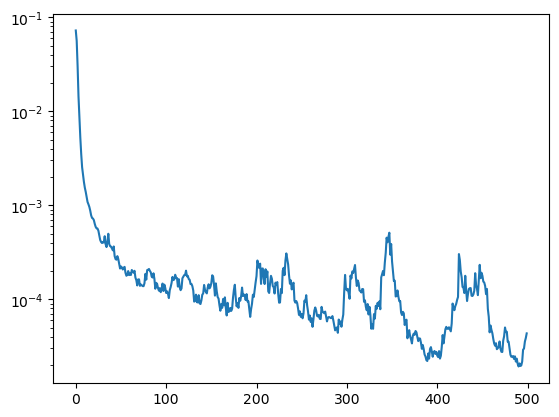

In [349]:
lr = 1e-3
epochs = 500
nbatch = 128

optim = optax.adamw(lr)

opt_state = optim.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def train_step(model, opt_state, x, y):
    loss_value, grads = eqx.filter_value_and_grad(loss)(model, x, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

@jax.jit
def subsample_data(data, n, rkey):
    rkey, subkey = jax.random.split(rkey, 2)
    return rkey, jax.random.choice(subkey, data, (n,))

@jax.jit
def permuted_data(data, rkey):
    rkey, subkey = jax.random.split(rkey, 2)
    return rkey, jax.random.permutation(subkey, data)

t = tqdm(range(epochs))
losses = []
for epoch in t:
    rkey, permed_data = permuted_data(jpsfarrs, rkey)
    for i in range(0, len(permed_data), nbatch):
        batch = permed_data[i:i+nbatch]
        batchr = batch.reshape(batch.shape[0], -1)
        model, opt_state, loss_value = train_step(model, opt_state, batchr, batchr)
    losses.append(float(loss_value))
    t.set_description(f'Loss: {loss_value:.4e}')

plt.semilogy(range(epochs), losses)

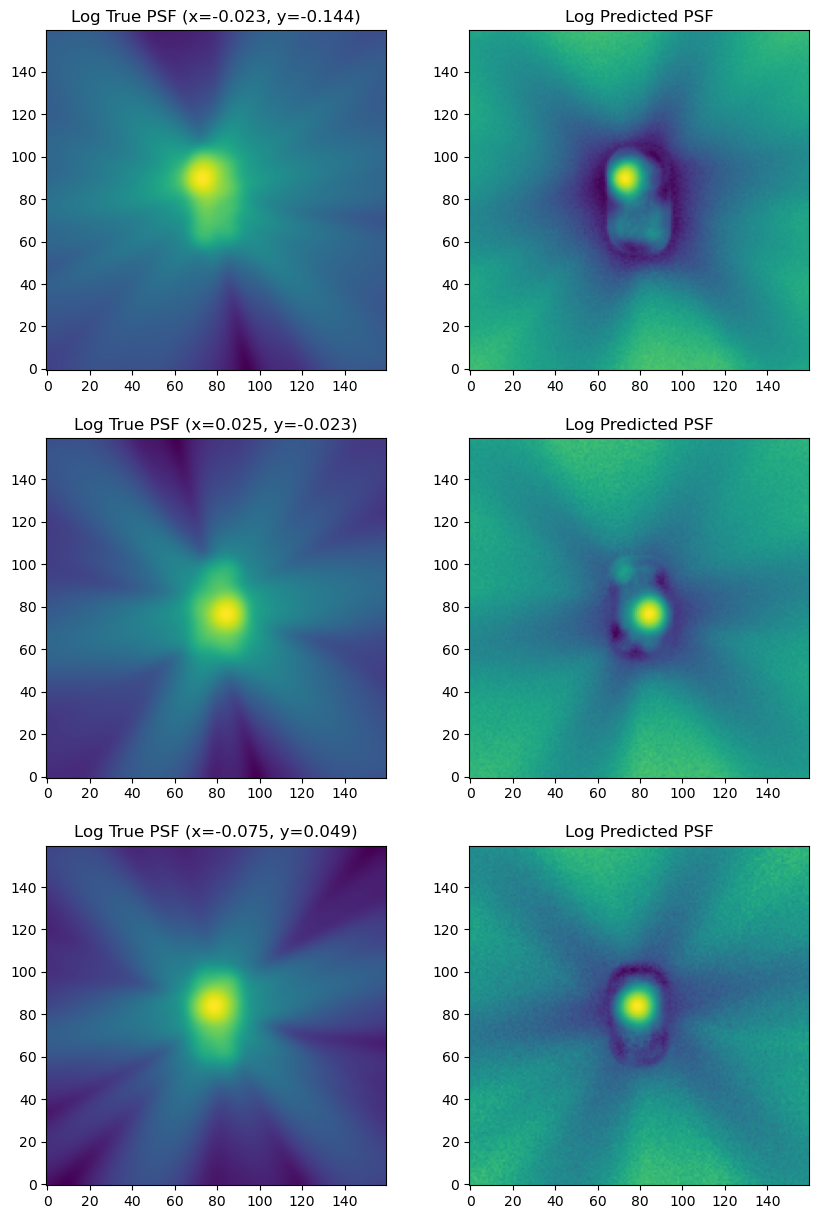

In [350]:
nsamples = 3
idxs = np.random.choice(len(psfarrs), nsamples, replace=False)

with jax.disable_jit():
    fig, axs = plt.subplots(nsamples, 2, figsize=(10, 5*nsamples))
    for i, idx in enumerate(idxs):
        pred = model(jpsfarrs[idx].ravel())

        axs[i, 0].imshow(jnp.log10(jpsfarrs[idx]), origin='lower')
        axs[i, 0].set_title(f'Log True PSF (x={psfxs[i]:.3f}, y={psfys[i]:.3f})')
        axs[i, 1].imshow(jnp.log10(pred.reshape(jpsfarrs.shape[1:])), origin='lower')
        axs[i, 1].set_title(f'Log Predicted PSF')

In [388]:


@jax.jit
def test_eval(i):
    return model(jpsfarrs[i].ravel())

# compile time
i = np.random.randint(len(psfarrs))
%time  pred = test_eval(i).block_until_ready() 

# run time
i2 = np.random.randint(len(psfarrs))
%time  pred = test_eval(i2).block_until_ready() 

CPU times: user 2.33 s, sys: 910 ms, total: 3.24 s
Wall time: 3.28 s
CPU times: user 698 μs, sys: 0 ns, total: 698 μs
Wall time: 814 μs


So even at this scale speed is ok, but having trouble getting the structure right.  Need to rethink the NN architecture - diffusion/flow-based models might improve regularity?